In [1]:
import sys
sys.path.append('..')

In [2]:
from src.l2_tools import *
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
df = pd.read_csv("../data/processed/L01_atb_profiles.csv")

ATB_total = df["ATB_total"].values
ATB_par = df["ATB_par"].values
ATB_per = df["ATB_per"].values

altitude = df["Altitude_m"].values

print(np.shape(altitude))


(4000,)


In [4]:
df = pd.read_csv("../data/processed/molecular_profiles_reference.csv")

AMB_clear = df["AMB_clear"].values
AMB_clear_parallel = df["AMB_clear_parallel"].values
AMB_clear_perpendicular = df["AMB_clear_perpendicular"].values
beta_ray = df["beta_ray"].values
beta_ray_parallel = df["beta_ray_parallel"].values
beta_ray_perpendicular = df["beta_ray_perpendicular"].values





In [10]:
INDEX_FOR_THE_CALIBRATION = 30000  # in  km 
LR = 30
reference_range = 100

beta_aerosol_total, __=L1_2_L2(ATB_total  , INDEX_FOR_THE_CALIBRATION , altitude , beta_ray , LR =LR
            , reference_range = reference_range , beta_aerosol_reference = 1e-9 ) 


beta_aerosol_par , __=L1_2_L2(ATB_par  , INDEX_FOR_THE_CALIBRATION , altitude , beta_ray_parallel , LR =LR
            , reference_range = reference_range , beta_aerosol_reference = 1e-9 ) 


beta_aerosol_per , __=L1_2_L2(ATB_per  , INDEX_FOR_THE_CALIBRATION , altitude , beta_ray_perpendicular , LR =LR
            , reference_range = reference_range , beta_aerosol_reference = 1e-9 ) 



beta_aerosol_total_fixed , mask_beta_par, mask_beta_per= filter_negative_backscatter(beta_parallel=beta_aerosol_par, beta_perpendicular=beta_aerosol_per)

calibration range 28500.0 m  to 31500.0 m
calibration range 28500.0 m  to 31500.0 m
calibration range 28500.0 m  to 31500.0 m


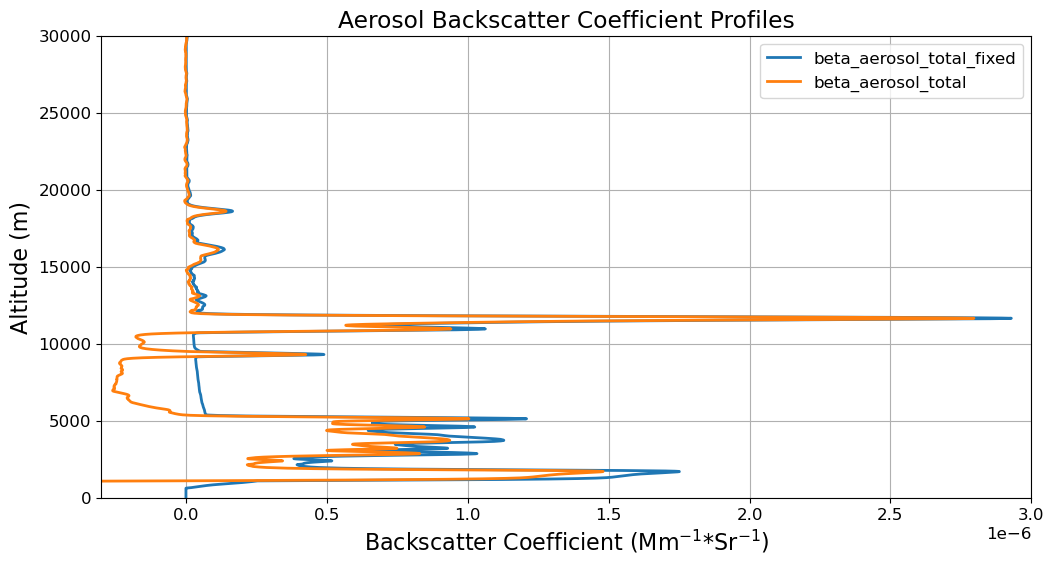

In [43]:
plt.figure(figsize=(12, 6))
plt.plot(beta_aerosol_total_fixed, altitude, label="beta_aerosol_total_fixed", linewidth=2)
# plt.plot(beta_aerosol_par, altitude, label="beta_aerosol_par", linewidth=2)
# plt.plot(beta_aerosol_per, altitude, label="beta_aerosol_per", linewidth=2)
plt.plot(beta_aerosol_total, altitude, label="beta_aerosol_total", linewidth=2 )
plt.xlabel("Backscatter Coefficient (Mm$^{-1}$*Sr$^{-1}$)")
plt.ylabel("Altitude (m)")
plt.title("Aerosol Backscatter Coefficient Profiles")
plt.legend()
plt.ylim(0, 30000)
plt.xlim(-3e-7, 3e-6)
plt.grid()
plt.show()